# Did COVID Kill Home Advantage? A Study of the Top 5 European Leagues

**Research Question:** Did home advantage disappear during the COVID season when stadiums were empty, and did it recover once fans returned?

**Hypothesis:** Home win rates dropped significantly during the COVID season (2019/20) compared to the last normal season (2018/19), and recovered in the first season fans returned (2020/21).

**Null Hypothesis:** There is no difference in home win rates across the three seasons — any observed differences are due to chance.

**Data Source:** Club Football Match Data (2000-2025) — Kaggle/GitHub (CC0 Public Domain)

**Leagues:** Premier League · La Liga · Bundesliga · Serie A · Ligue 1

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Imports successful!')

Imports successful!


---
## 2. Data Loading & Cleaning

In [2]:
# Load the dataset
df = pd.read_csv('Matches.csv', low_memory=False)

# Filter to top 5 European leagues only
top5 = ['E0', 'SP1', 'D1', 'I1', 'F1']
df = df[df['Division'].isin(top5)].copy()

# Convert date column
df['MatchDate'] = pd.to_datetime(df['MatchDate'])

print(f'Total matches loaded: {len(df):,}')
print(df.head())

Total matches loaded: 43,708
  Division  MatchDate MatchTime   HomeTeam    AwayTeam  HomeElo  AwayElo  \
0       F1 2000-07-28       NaN  Marseille      Troyes  1686.34  1586.57   
1       F1 2000-07-28       NaN   Paris SG  Strasbourg  1714.89  1642.51   
3       F1 2000-07-29       NaN    Auxerre       Sedan  1635.58  1624.22   
4       F1 2000-07-29       NaN   Bordeaux        Metz  1734.34  1673.11   
5       F1 2000-07-29       NaN   Guingamp  St Etienne  1578.51  1620.74   

   Form3Home  Form5Home  Form3Away  ...  MaxUnder25  HandiSize  HandiHome  \
0        0.0        0.0        0.0  ...         NaN        NaN        NaN   
1        0.0        0.0        0.0  ...         NaN        NaN        NaN   
3        0.0        0.0        0.0  ...         NaN        NaN        NaN   
4        0.0        0.0        0.0  ...         NaN        NaN        NaN   
5        0.0        0.0        0.0  ...         NaN        NaN        NaN   

  HandiAway  C_LTH  C_LTA C_VHD  C_VAD  C_HTB  C_PH

The dataset contains 43,708 matches across the top 5 European leagues from 2000 to 2025. Several columns such as betting odds and advanced match stats show NaN values for earlier seasons — this is expected since that data was not recorded at the time. For this analysis we only use FTResult, Division, and MatchDate, all of which are complete for the seasons we are studying.

In [3]:
# Split into three seasons using date filters
pre_covid = df[(df['MatchDate'] >= '2018-08-01') & (df['MatchDate'] <= '2019-07-31')].copy()
covid     = df[(df['MatchDate'] >= '2019-08-01') & (df['MatchDate'] <= '2020-07-31')].copy()
post_covid = df[(df['MatchDate'] >= '2020-08-01') & (df['MatchDate'] <= '2021-07-31')].copy()

# Drop rows with missing result
pre_covid  = pre_covid.dropna(subset=['FTResult'])
covid      = covid.dropna(subset=['FTResult'])
post_covid = post_covid.dropna(subset=['FTResult'])

print(f'2018/19 (Pre-COVID):  {len(pre_covid):,} matches')
print(f'2019/20 (COVID):      {len(covid):,} matches')
print(f'2020/21 (Post-COVID): {len(post_covid):,} matches')

2018/19 (Pre-COVID):  1,826 matches
2019/20 (COVID):      1,715 matches
2020/21 (Post-COVID): 1,836 matches


---
## 3. Descriptive Statistics

In [4]:
# Calculate home win rates for each season
pre_home_rate  = (pre_covid['FTResult'] == 'H').mean() * 100
covid_home_rate = (covid['FTResult'] == 'H').mean() * 100
post_home_rate = (post_covid['FTResult'] == 'H').mean() * 100

print('=== HOME WIN RATES BY SEASON ===')
print()
print(f'2018/19 (Pre-COVID):')
print(f'  Home wins:  {(pre_covid["FTResult"] == "H").sum():,} ({pre_home_rate:.1f}%)')
print(f'  Draws:      {(pre_covid["FTResult"] == "D").sum():,} ({(pre_covid["FTResult"] == "D").mean()*100:.1f}%)')
print(f'  Away wins:  {(pre_covid["FTResult"] == "A").sum():,} ({(pre_covid["FTResult"] == "A").mean()*100:.1f}%)')
print()
print(f'2019/20 (COVID):')
print(f'  Home wins:  {(covid["FTResult"] == "H").sum():,} ({covid_home_rate:.1f}%)')
print(f'  Draws:      {(covid["FTResult"] == "D").sum():,} ({(covid["FTResult"] == "D").mean()*100:.1f}%)')
print(f'  Away wins:  {(covid["FTResult"] == "A").sum():,} ({(covid["FTResult"] == "A").mean()*100:.1f}%)')
print()
print(f'2020/21 (Post-COVID):')
print(f'  Home wins:  {(post_covid["FTResult"] == "H").sum():,} ({post_home_rate:.1f}%)')
print(f'  Draws:      {(post_covid["FTResult"] == "D").sum():,} ({(post_covid["FTResult"] == "D").mean()*100:.1f}%)')
print(f'  Away wins:  {(post_covid["FTResult"] == "A").sum():,} ({(post_covid["FTResult"] == "A").mean()*100:.1f}%)')

=== HOME WIN RATES BY SEASON ===

2018/19 (Pre-COVID):
  Home wins:  817 (44.7%)
  Draws:      472 (25.8%)
  Away wins:  537 (29.4%)

2019/20 (COVID):
  Home wins:  758 (44.2%)
  Draws:      418 (24.4%)
  Away wins:  539 (31.4%)

2020/21 (Post-COVID):
  Home wins:  731 (39.8%)
  Draws:      467 (25.4%)
  Away wins:  638 (34.7%)


---
## 4. Visualizations

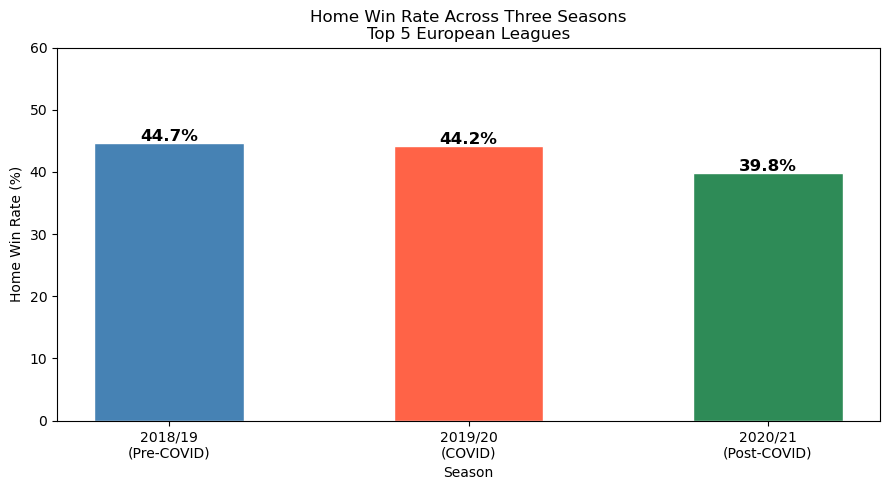

In [5]:
# Figure 1: Home win rate by season
seasons = ['2018/19\n(Pre-COVID)', '2019/20\n(COVID)', '2020/21\n(Post-COVID)']
home_win_rates = [pre_home_rate, covid_home_rate, post_home_rate]
colors = ['steelblue', 'tomato', 'seagreen']

plt.figure(figsize=(9, 5))
bars = plt.bar(seasons, home_win_rates, color=colors, edgecolor='white', width=0.5)
for bar, rate in zip(bars, home_win_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.title('Home Win Rate Across Three Seasons\nTop 5 European Leagues')
plt.xlabel('Season')
plt.ylabel('Home Win Rate (%)')
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

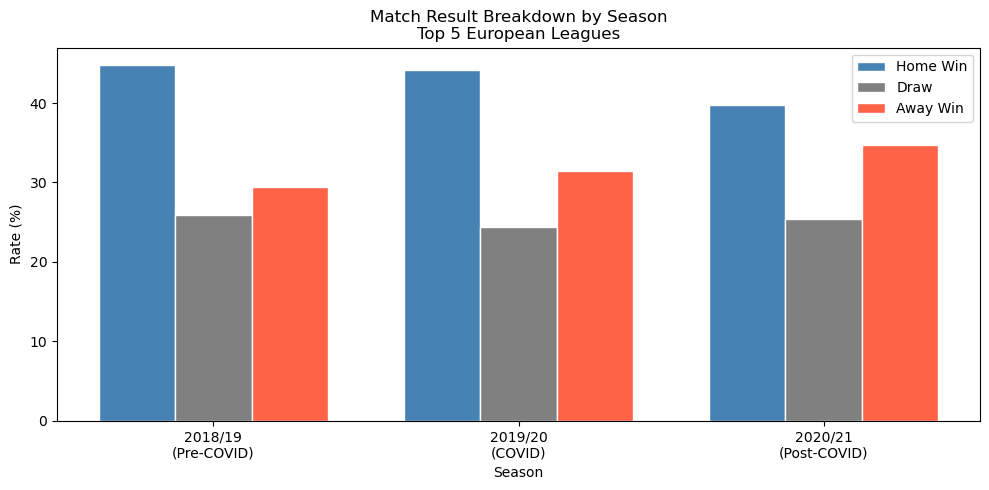

In [6]:
# Figure 2: Full result breakdown side by side
home_rates = [pre_home_rate, covid_home_rate, post_home_rate]
draw_rates = [
    (pre_covid['FTResult'] == 'D').mean() * 100,
    (covid['FTResult'] == 'D').mean() * 100,
    (post_covid['FTResult'] == 'D').mean() * 100
]
away_rates = [
    (pre_covid['FTResult'] == 'A').mean() * 100,
    (covid['FTResult'] == 'A').mean() * 100,
    (post_covid['FTResult'] == 'A').mean() * 100
]

x = np.arange(len(seasons))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, home_rates, width, label='Home Win', color='steelblue', edgecolor='white')
plt.bar(x,         draw_rates, width, label='Draw',     color='gray',      edgecolor='white')
plt.bar(x + width, away_rates, width, label='Away Win', color='tomato',    edgecolor='white')
plt.xticks(x, seasons)
plt.title('Match Result Breakdown by Season\nTop 5 European Leagues')
plt.xlabel('Season')
plt.ylabel('Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Initial Observations

- The home win rate was **44.7%** in the last normal season (2018/19), **44.2%** during COVID (2019/20), and dropped further to **39.8%** in the first season fans returned (2020/21).
- Surprisingly, the COVID season barely affected the home win rate. The bigger drop came **after** fans returned.
- This challenges the common assumption that empty stadiums hurt home teams the most. The data suggests something more complex may be happening.
- Away win rates jumped from 29.4% to 34.7% in 2020/21 — the biggest shift across all three seasons.
- Further analysis using a permutation test and bootstrapping will formally test whether these differences are statistically significant.